In [1]:
from glob import glob
import json
import pandas as pd

map_topic_to_idx = {'Regional Folklore and Myths': 1,
 'Local Health and Wellness': 2,
 'Local Environmental Issues': 3,
 'Neighborhood Stories': 4,
 'Local Sports and Activities': 5,
 'Local Technology and Innovation': 6,
 'Local Arts and Culture': 7,
 'Cybersecurity News': 8,
 'Local Politics and Governance': 9,
 'Small and Medium Enterprises': 10,
 'Local News': 11,
 'Local Economy and Market': 12,
 'Local Education Systems': 13,
 'News Stories': 14,
 'Company Policies': 15,
 'Regional Cuisine and Recipes': 16,
 'Incident Report': 17
 }

files = glob("../experiments/RepLiQA/retrival_experiments/*.json")

results = []
for file in files:
    with open(file, "r") as f:
        data = json.load(f)
        result =  data[1:]
        for d in result:
            d['tag'] = d['tag'].replace("_test", "")
            d['k'] = int(data[0]['k'])
            d['fetch_k'] = int(data[0]['fetch_k'])
            d['threshold'] = float(data[0]['threshold'])
            d['retrieved_loras'] = d['retrieved_loras'].split("-")
            d['loaded_correctly'] = 1 if (d['tag'] in d['retrieved_loras']) else 0
            d['perc_loaded'] = 1/len(d['retrieved_loras']) if (d['tag'] in d['retrieved_loras']) else 0
            d['number_of_retrieved'] = len(d['retrieved_loras'])

            results.append(d)
data = pd.DataFrame(results)

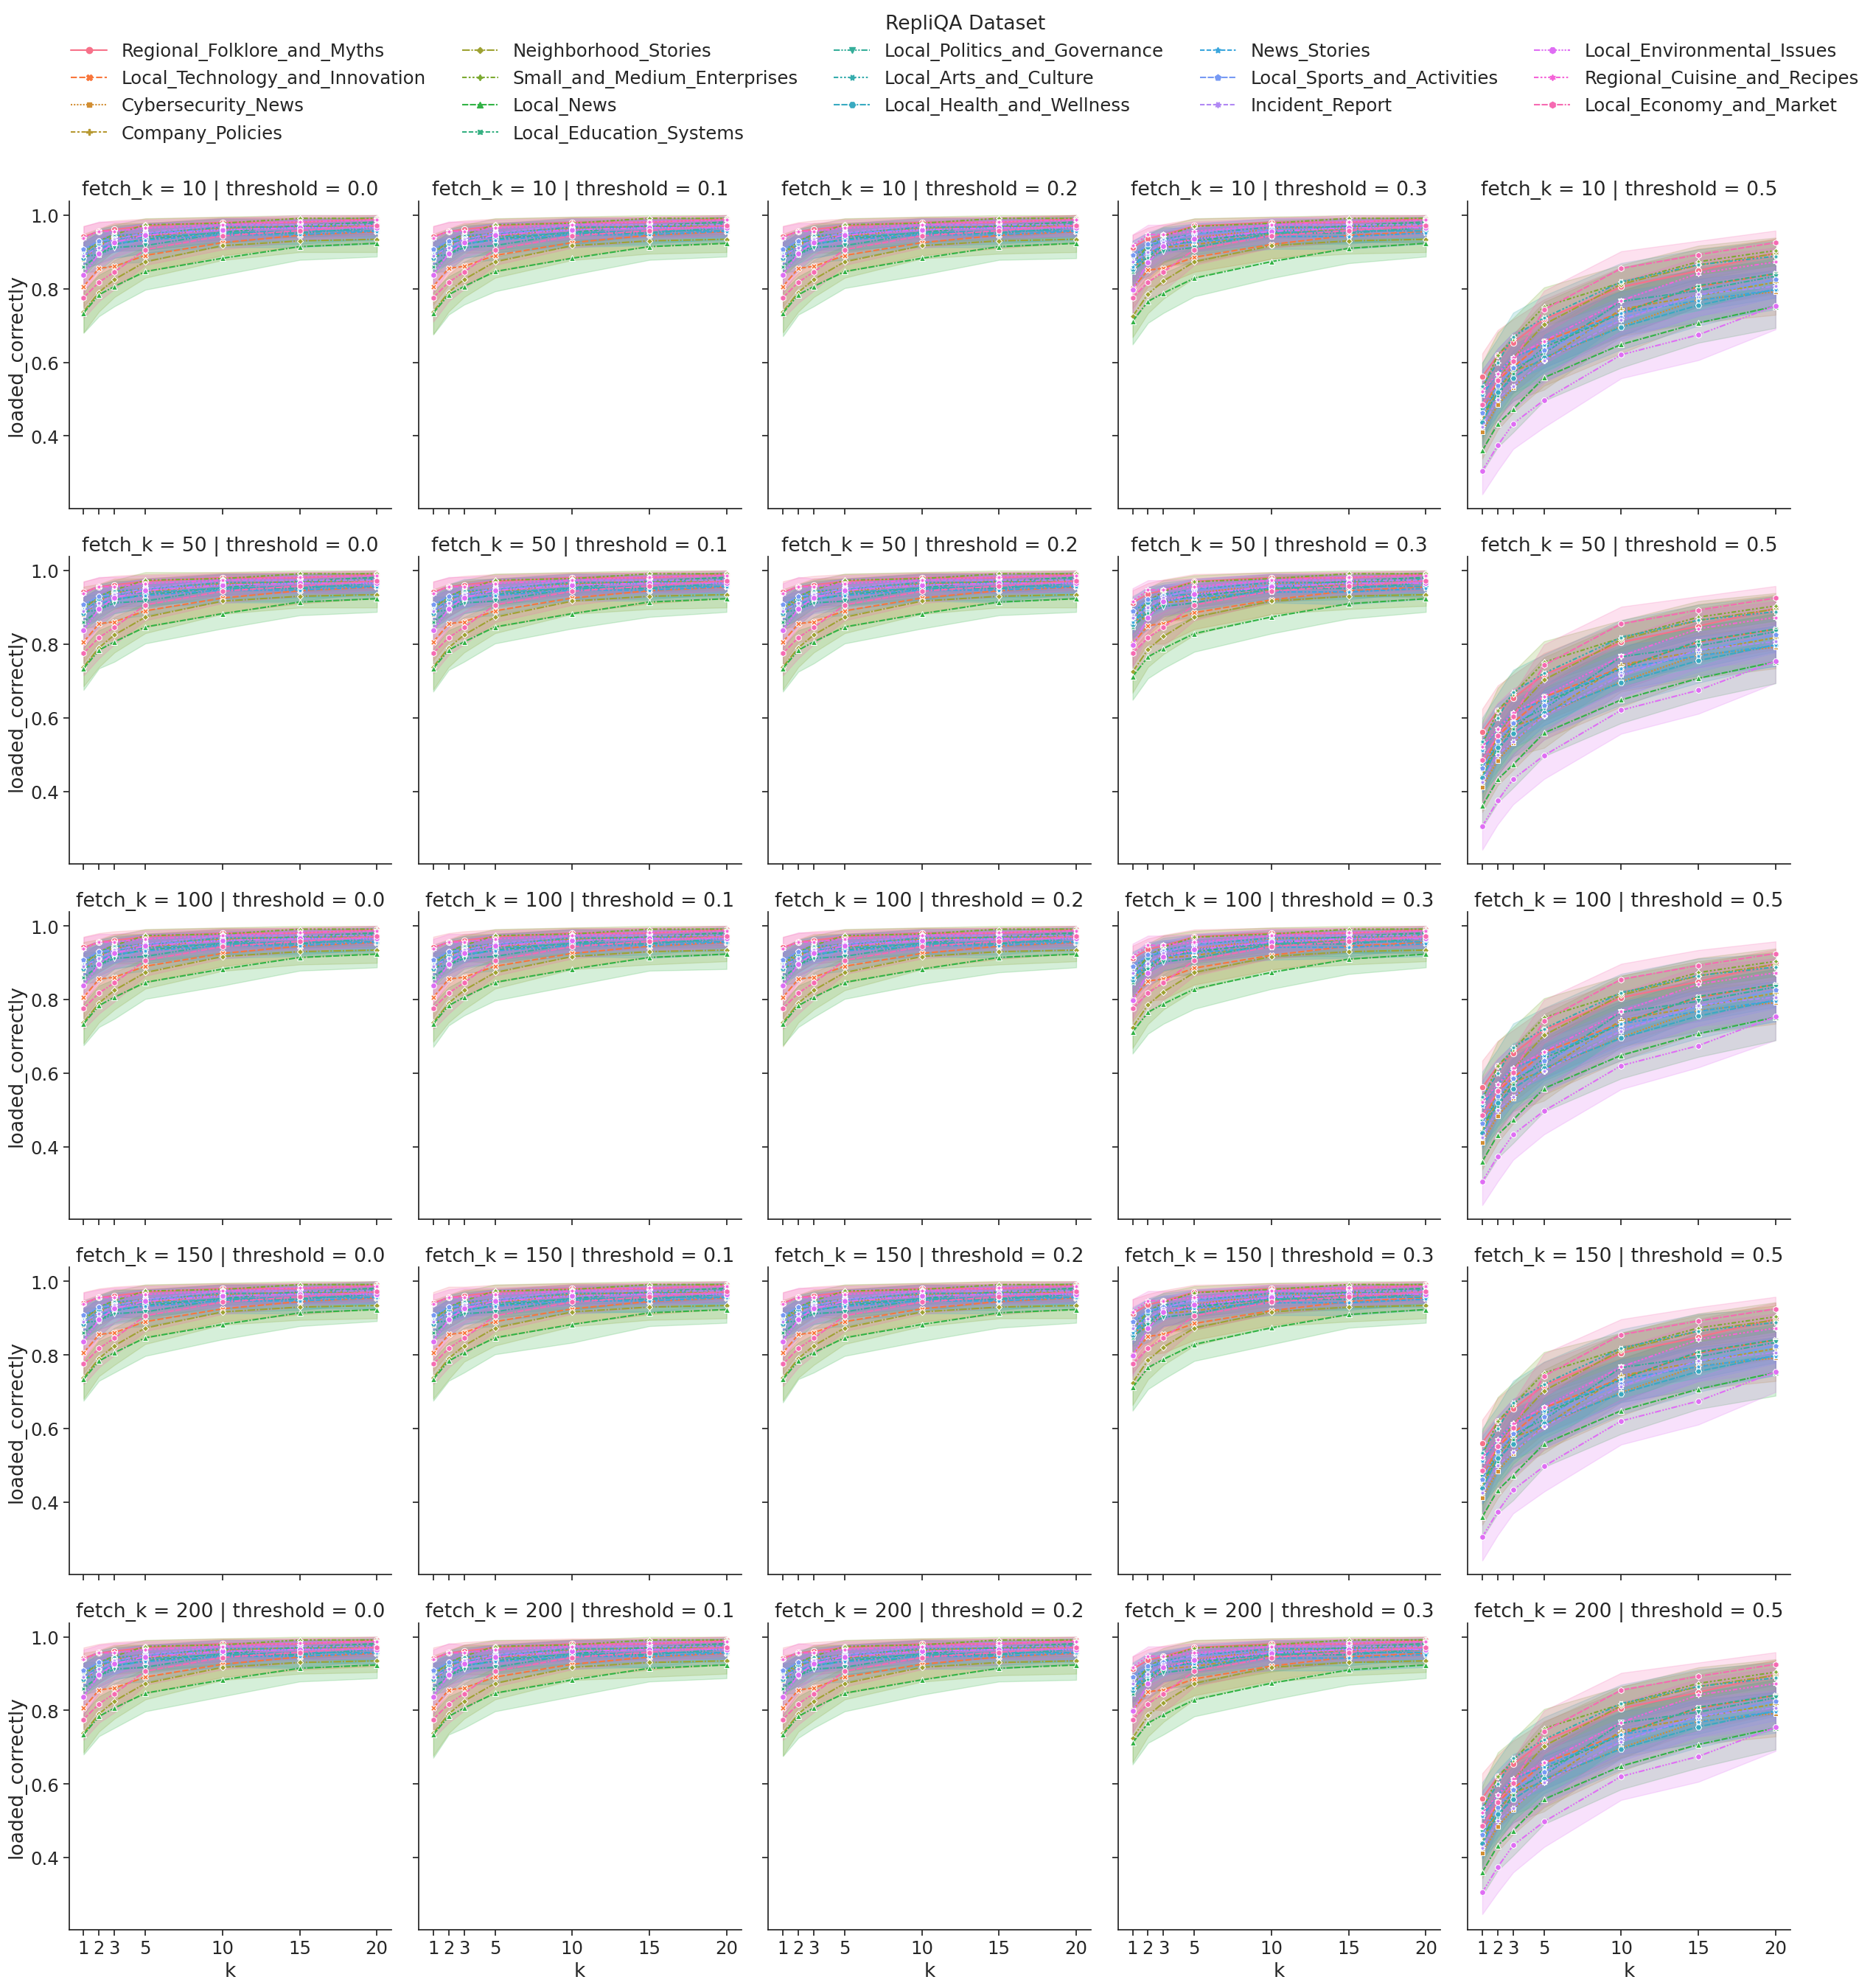

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

x_ticks = list(set(data['k']))
sns.set_theme(font_scale=1.6)
sns.set_style("ticks", {"grid.color": ".6", "grid.linestyle": "solid"})

f = sns.relplot(x='k', y='loaded_correctly', hue='tag', style='tag',kind="line", data=data, markers=True, row="fetch_k", col="threshold", legend='auto')
sns.move_legend(f, loc='lower center', ncol=5, bbox_to_anchor=(.45, 1), title='RepliQA Dataset')
plt.xticks(x_ticks)


plt.savefig("../figs/retrieval_repliqa_full.pdf", bbox_inches = 'tight',
    pad_inches = 0)



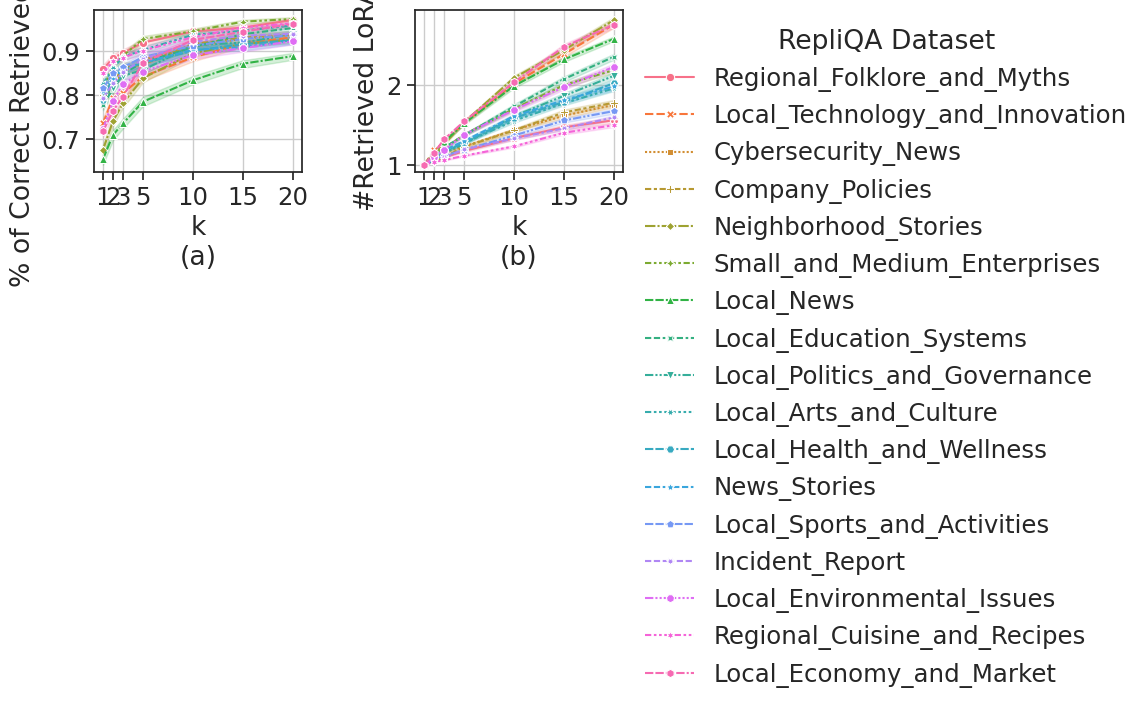

In [3]:
sns.set_style(style='ticks')
fig, ax = plt.subplots(1,2,  figsize=(12, 5.1))

ax[0] = sns.lineplot(x='k', y='loaded_correctly', hue='tag', style='tag', data=data, markers=True, ax=ax[0], legend=None)
ax[1] = sns.lineplot(x='k', y='number_of_retrieved', hue='tag', style='tag', data=data, markers=True, ax=ax[1])

sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1, 1.02),title='RepliQA Dataset', frameon=False)
ax[0].set(ylabel='% of Correct Retrieved LoRAs')
ax[1].set(ylabel='#Retrieved LoRAs')

ax[0].set_xticks(x_ticks)
ax[1].set_xticks(x_ticks)


ax[0].set(xlabel='k\n(a)')
ax[1].set(xlabel='k\n(b)')

ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig("../figs/retrieved_repliqa_combined.pdf", bbox_inches='tight')


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
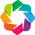

:Chord   [source,target]   (color,value,size)

In [4]:
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')
links = []
data_k20 = data[(data['k'] == 20) & (data['fetch_k'] == 200) & (data['threshold'] == 0.0)]

tags = list(set(data['tag']))
map_tag_to_number = {}

for idx, t in enumerate(tags):
    map_tag_to_number[t] =idx

palette = [
    "#4B8A3D",  # Forest Green
    "#C05C34",  # Rust
    "#F2C12E",  # Mustard Yellow
    "#B9D3C2",  # Light Sage Green
    "#C1A1B8",  # Lavender Gray
    "#6E4B3A",  # Mocha
    "#D1B79C",  # Light Taupe
    "#A6D8D3",  # Soft Aqua
    "#A67C52",  # Caramel
    "#B8B8B8",  # Light Gray
    "#FF6F61",  # Coral Red
    "#F1A7B6",  # Light Pink
    "#99B2A6",  # Dusty Teal
    "#D0C8A4",  # Olive Green
    "#3C8A77",  # Teal
    "#8F7F4F",  # Olive Brown
    "#C1C3D1"   # Misty Lavender
]


domain_colors = {d: palette[map_tag_to_number[d]] for d in tags}
# create links
for idx,d in data_k20.iterrows():
    for t in d['retrieved_loras']:
        if t:
            links.append({'source':map_tag_to_number[d['tag']], "target":map_tag_to_number[t], "value":1, "color":domain_colors[d['tag']]})

nodes = []
for t in tags:
    nodes.append({"name": t, "idx": map_tag_to_number[t], "color": domain_colors[t]})

nodes_df = pd.DataFrame(nodes)

nodes = hv.Dataset(nodes_df, 'idx')

links = pd.DataFrame(links)
links = links.groupby(["source", "target", "color"]).sum().reset_index()

def remap_value(val):
    return (val - links['value'].min()) / (links['value'].max() - links['value'].min()) * (2 - 0.1) + 0.1

links['size'] = links['value'].apply(remap_value)
chord = hv.Chord((links, nodes)).select(value=(5, None))

diagram = chord.opts(
    opts.Chord(

        edge_color="color",
        edge_line_width='size',
        labels='name',
        node_color='color',
        width=1000,
        height=1000,
    )
)
diagram


In [ ]:
## Inference

aclora_scores = "../experiments/RepLiQA/inference/aclora/abe66ada92133a569c2c5d9ef49fe511_grade.json"
perfect_selection = glob("../experiments/RepLiQA/inference/perfect_selection/*_grade.json")

full_data = []
with open(aclora_scores, "r") as fp:
    data = json.load(fp)
for d in data:
    d['grade'] = int(d['grade'][0])
    d['type'] = "ACLoRA"
    full_data.append({**d, "topic_idx":map_topic_to_idx[d['document_topic']]})

for f in perfect_selection:
    task = f.split("/")[-4]

    with open(f, "r") as fp:
        data = json.load(fp)
    for d in data:
      d['grade'] = int(d['grade'][0])
      full_data.append({**d, "topic_idx":map_topic_to_idx[d['document_topic']], "type":"Single LoRA\n(Perfect Selection)"})

df=pd.DataFrame(full_data)

<Figure size 640x480 with 0 Axes>

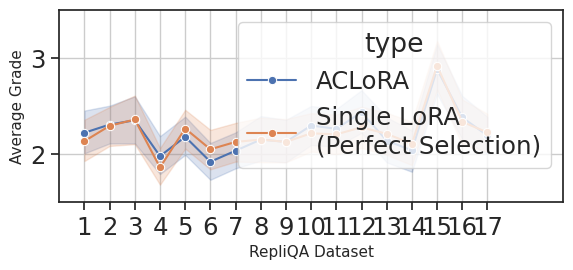

In [6]:
import seaborn as sns
plt.clf()

plt.figure(figsize=(6.5,2.5))

g = sns.lineplot(df, x="topic_idx", y="grade", markers=True, hue='type',marker="o")
g.set_yticks(g.get_yticks())
g.set_xticks(g.get_xticks())
g.set_ylabel('Average Grade', fontsize=11)
g.set_xlabel('RepliQA Dataset', fontsize=11)

g.set_ylim(1.5, 3.5)
g.set_xticks(range(1,18))

g.grid()
fig = g.get_figure()
fig.savefig("../figs/grade_inference_repliqa.pdf", bbox_inches='tight')

In [ ]:

## Knowledge Injection
queries = {}
## Base Model evaluation
with open("../experiments/RepLiQA/base/118786d3a5a39d003a245e0bc34a1dc7.json") as fp:
    base = json.load(fp)

for b in base:
    queries[b['question']] = [int(g) for g in b['grade']]

full_data = []
for f in perfect_selection:

    task = f.split("/")[-1]

    with open(f, "r") as fp:
        data = json.load(fp)

    for d in data:
      d['grade'] = int(d['grade'][0])
      full_data.append({**d, "topic_idx":map_topic_to_idx[d['document_topic']], "grade_base":queries[d['question']], "improvement":d['grade']-max(queries[d['question']]),"max_base_grade":max(queries[d['question']]) })

df = pd.DataFrame(full_data)

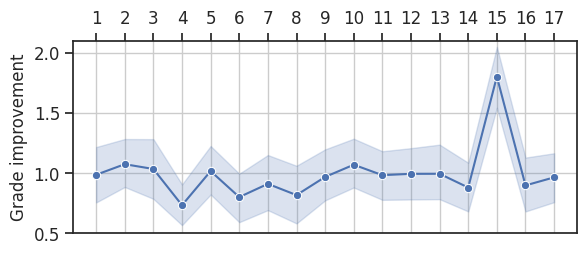

In [8]:
plt.figure(figsize=(6.5,2.5))
sns.set_theme(font_scale=1.1)
sns.set_style(style='ticks')

g = sns.lineplot(df, x="topic_idx", y="improvement", markers=True, marker="o")
g.set_yticks(g.get_yticks())
g.set_ylabel('Grade improvement', fontsize=12)
g.set_xlabel('')
g.set_ylim(0.5, 2.1)
g.set_xticks(range(1,18))

g.xaxis.tick_top()

g.grid()

fig = g.get_figure()
fig.savefig("../figs/grade_improvement_all_tasks_v2.pdf", bbox_inches='tight')


In [17]:
import pandas as pd


grade_len = len('Confidence Interval for RepliQA-Grades-')
hint_len = len('Confidence Interval for hint RepliQA-Grades-')

columns = ['dataset', 'dataset_idx', 'base', 'base ci', 'hint', 'hint ci']
df_hint = pd.DataFrame(columns=columns)

with open('../experiments/RepLiQA/inference/hinting/hint_intervals.txt') as file:
    start_parse = 0
    counter = 0
    base_mean = -1
    base_ac = ''
    dataset_name = ''
    for line in file:
        ln = line.rstrip()
        if ln.startswith('##') :
            start_parse += 1
            continue

        if start_parse == 1 :
            splits = ln.split(':')

            if counter % 2 == 0:
                dataset_name = splits[0][grade_len:]
                base_mean = float(splits[2].strip().split(' ')[0])
                base_ac = splits[3].strip()
                # print (base_mean)
            else :
                # dataset_name = splits[0][hint_len:]
                hint_mean = float(splits[2].strip().split(' ')[0])
                hint_ac = splits[3].strip()
                # print (dataset_name)
                df_hint.loc[counter/2] = [dataset_name, map_topic_to_idx[dataset_name], base_mean, base_ac, hint_mean, hint_ac]

            counter += 1

In [18]:
df_hint = df_hint.reset_index(drop=True)

df_hint

,dataset,dataset_idx,base,base ci,hint,hint ci
0,Local Sports and Activities,5,1.805755,"(1.6257194244604318, 1.9928057553956835)",2.280576,"(2.0575539568345325, 2.5035971223021583)"
1,Local Education Systems,13,1.929688,"(1.7341796875, 2.125)",2.171875,"(1.953125, 2.4220703125)"
2,Company Policies,15,2.435294,"(2.164705882352941, 2.7058823529411766)",2.905882,"(2.6588235294117646, 3.1411764705882352)"
3,Regional Cuisine and Recipes,16,1.940299,"(1.7313432835820894, 2.1492537313432836)",2.380597,"(2.1417910447761193, 2.5970149253731343)"
4,Small and Medium Enterprises,10,1.966216,"(1.7837837837837838, 2.1486486486486487)",2.216216,"(2.0133445945945945, 2.425675675675676)"
5,Local Arts and Culture,7,1.739437,"(1.5633802816901408, 1.9154929577464788)",2.183099,"(1.9647887323943662, 2.3943661971830985)"
6,Local Politics and Governance,9,1.779661,"(1.5847457627118644, 1.9745762711864407)",2.093220,"(1.8644067796610169, 2.3220338983050848)"
7,Incident Report,17,1.675000,"(1.51875, 1.84375)",2.212500,"(2.01859375, 2.41265625)"
8,News Stories,14,1.618321,"(1.4578244274809162, 1.7940839694656487)",2.000000,"(1.8091603053435115, 2.2139312977099235)"
9,Local Technology and Innovation,6,1.906475,"(1.7050359712230216, 2.093705035971223)",1.978417,"(1.79136690647482, 2.179856115107914)"


In [21]:
df_melted = df_hint.melt(id_vars="dataset_idx", value_vars=["base", "hint"],
                    var_name="series", value_name="value")

df_melted


,dataset_idx,series,value
0,5,base,1.805755
1,13,base,1.929688
2,15,base,2.435294
3,16,base,1.940299
4,10,base,1.966216
5,7,base,1.739437
6,9,base,1.779661
7,17,base,1.675000
8,14,base,1.618321
9,6,base,1.906475


1.927607419284585 2.230409412576185


<Figure size 640x480 with 0 Axes>

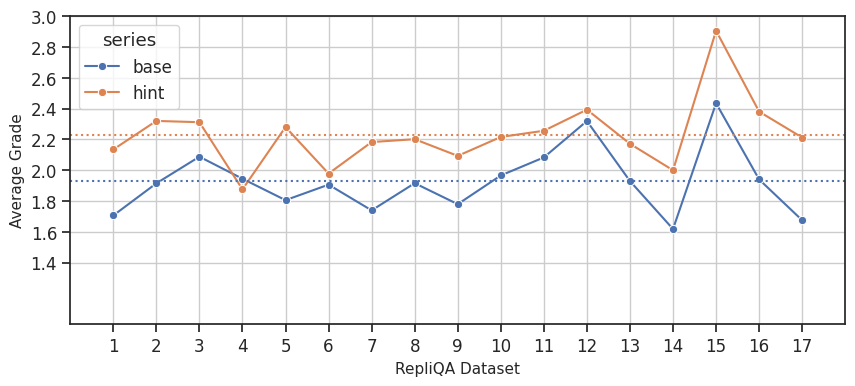

In [23]:
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt


plt.clf()

plt.figure(figsize=(10,4))

g = sns.lineplot(df_melted, x="dataset_idx", y="value", markers=True, hue='series',marker="o")
g.set_yticks(g.get_yticks())
g.set_xticks(g.get_xticks())
g.set_ylabel('Average Grade', fontsize=11)
g.set_xlabel('RepliQA Dataset', fontsize=11)

g.set_ylim(1, 3)
g.set_xticks(range(1,18))
# plt.xticks(rotation = 45, ha="right")
g.grid()

base_mean = df_melted.loc[df_melted['series'] == 'base', "value"].mean()
hint_mean = df_melted.loc[df_melted['series'] == 'hint', "value"].mean()

print (base_mean, hint_mean)

plt.axhline(y=base_mean, color=g.get_lines()[0].get_color(), linestyle=":")
plt.axhline(y=hint_mean, color=g.get_lines()[1].get_color(), linestyle=":")


fig = g.get_figure()

fig.savefig("../figs/hint_grade_improvement_repliqa.pdf", bbox_inches='tight')